<a href="https://colab.research.google.com/github/Joel-Alejandro-DM/DrivenPath/blob/main/Practica3%3A%20Convoluci%C3%B3n%20y%20filtros%20espaciales/python/Pr%C3%A1ctica3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!wget -nc "https://raw.githubusercontent.com/Jegovila/cursoVR/main/Practica3%3A%20Convoluci%C3%B3n%20y%20filtros%20espaciales/data/lena.bmp"

--2025-09-29 05:58:33--  https://raw.githubusercontent.com/Jegovila/cursoVR/main/Practica3%3A%20Convoluci%C3%B3n%20y%20filtros%20espaciales/data/lena.bmp
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 786486 (768K) [image/bmp]
Saving to: ‘lena.bmp’

lena.bmp            100%[===================>] 768.05K  3.40MB/s    in 0.2s    

2025-09-29 05:58:35 (3.40 MB/s) - ‘lena.bmp’ saved [786486/786486]



In [4]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt

# Suavizado

Filtro Box

In [5]:
n = 7
h = np.ones((n, n), np.float32)/(n*n)

Filtro Gauss

In [15]:
h = np.matrix('1 4 6 4 1;4 16 24 16 4;6 24 36 24 6;4 16 24 16 4;1 4 6 4 1')
h = h * (1/256)

Suavizado

In [16]:
I1 = cv2.imread("lena.bmp")
I1 = cv2.cvtColor(I1, cv2.COLOR_BGR2GRAY)
I2 = cv2.filter2D(I1, -1, h)

Desplegar resultados

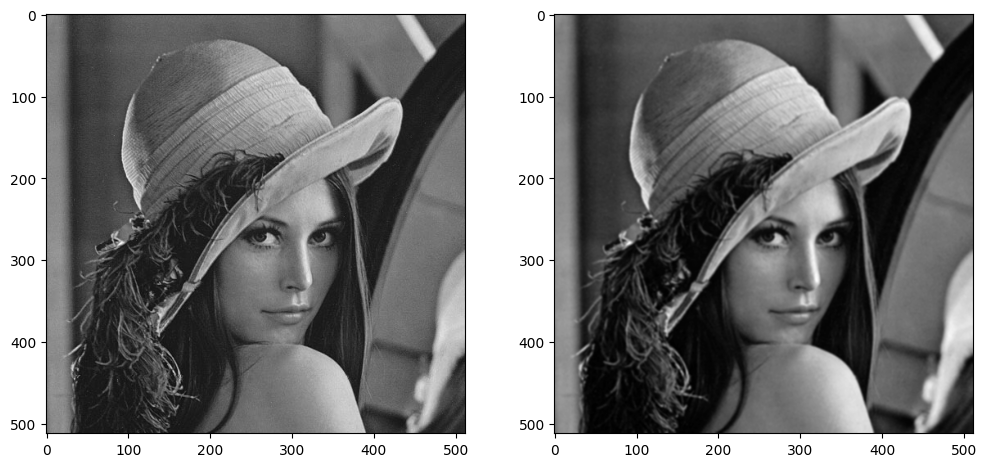

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(10,10))
fig.tight_layout()
plt.clf()

plt.subplot(1,2,1)
plt.imshow(I1, cmap="gray")
plt.subplot(1,2,2)
plt.imshow(I2, cmap="gray")

# Bordes

## Sobel

Filtros

In [38]:
# BOX
n = 3
h = np.ones((n, n), np.float32)/(n*n)

# SOBEL
hx = np.matrix('-1 0 1;-2 0 2;-1 0 1')
hy = np.matrix('-1 -2 -1;0 0 0;1 2 1')

In [41]:
I1 = cv2.imread("lena.bmp")

gray = cv2.cvtColor(I1, cv2.COLOR_BGR2GRAY)
gray_suavizado = cv2.filter2D(gray, -1, h)

# sin suavizar
sx = cv2.filter2D(gray, -1, hx)
sy = cv2.filter2D(gray, -1, hy)
s = cv2.addWeighted(sx, 0.5, sy, 0.5, 0)
s = cv2.inRange(s,50,255)

# suavizado
sx_suavizado = cv2.filter2D(gray_suavizado, -1, hx)
sy_suavizado = cv2.filter2D(gray_suavizado, -1, hy)
s_suavizado = cv2.addWeighted(sx_suavizado, 0.5, sy_suavizado, 0.5, 0)
s_suavizado = cv2.inRange(s_suavizado,50,255)

Resultados

Text(0.5, 1.0, 'Suavizada')

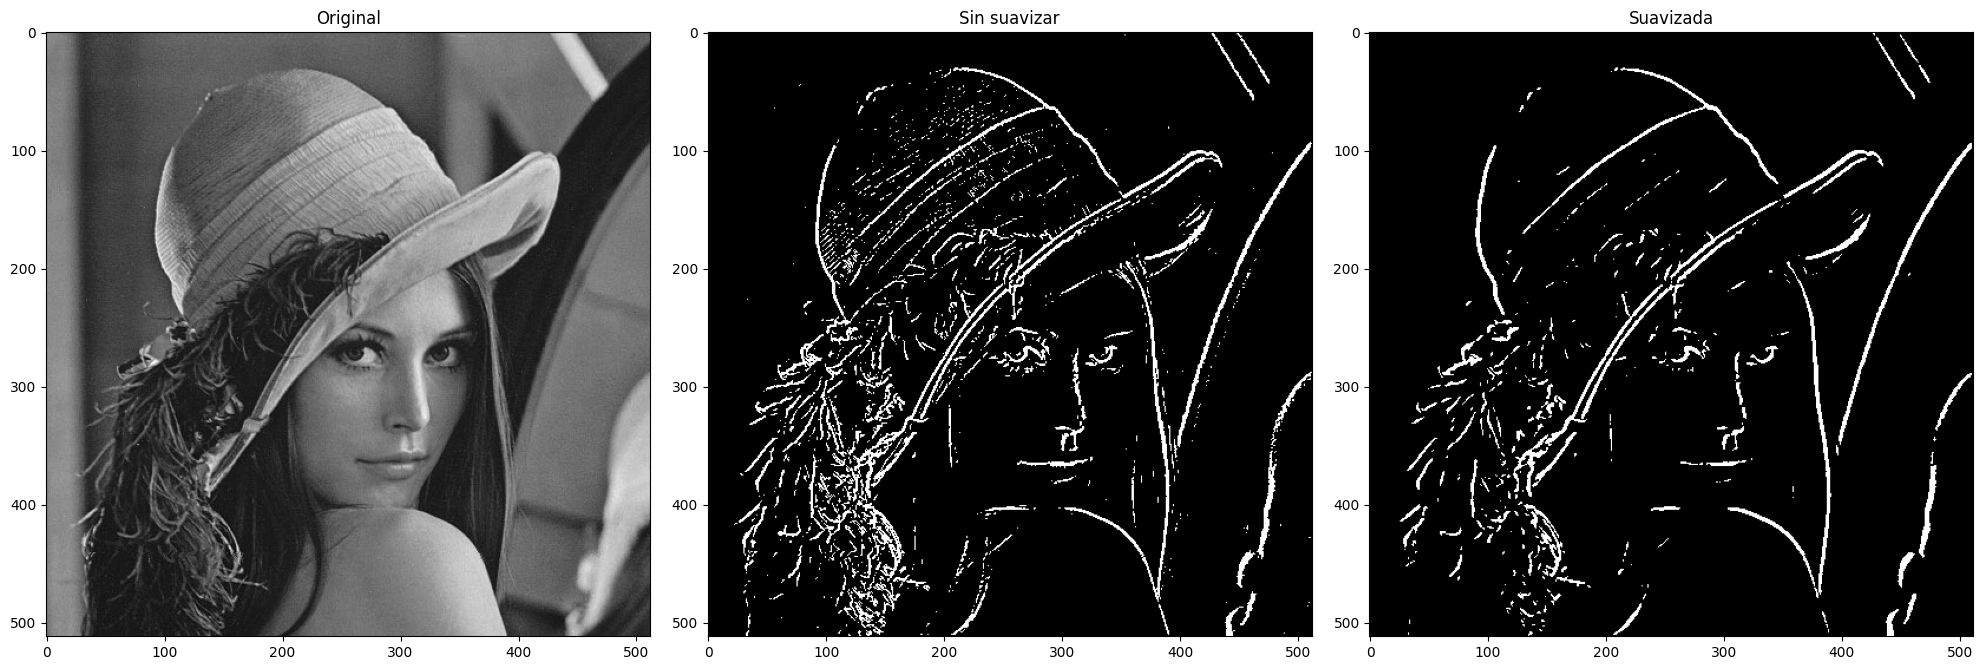

In [51]:
fig, ax = plt.subplots(1, 3, figsize=(20,10))
fig.tight_layout()
plt.clf()

plt.subplot(1,3,1)
plt.imshow(gray, cmap="gray")
plt.title("Original")
plt.subplot(1,3,2)
plt.imshow(s, cmap="gray")
plt.title("Sin suavizar")
plt.subplot(1,3,3)
plt.imshow(s_suavizado, cmap="gray")
plt.title("Suavizada")

## Laplace

In [52]:
# BOX
n = 3
h = np.ones((n, n), np.float32)/(n*n)

# Laplace
hl = np.matrix('1 1 1;1 -8 1;1 1 1')

In [63]:
I1 = cv2.imread("lena.bmp")

gray = cv2.cvtColor(I1, cv2.COLOR_BGR2GRAY)
gray_s = cv2.filter2D(gray, -1, h)

# --- sin suavizar
dst = cv2.filter2D(gray, -1, hl)
dst = cv2.inRange(dst,60,255)

# --- Suavizada
dst_s= cv2.filter2D(gray_s, -1, hl)
dst_s = cv2.inRange(dst_s,15,255)

Resultados

Text(0.5, 1.0, 'Suavizada')

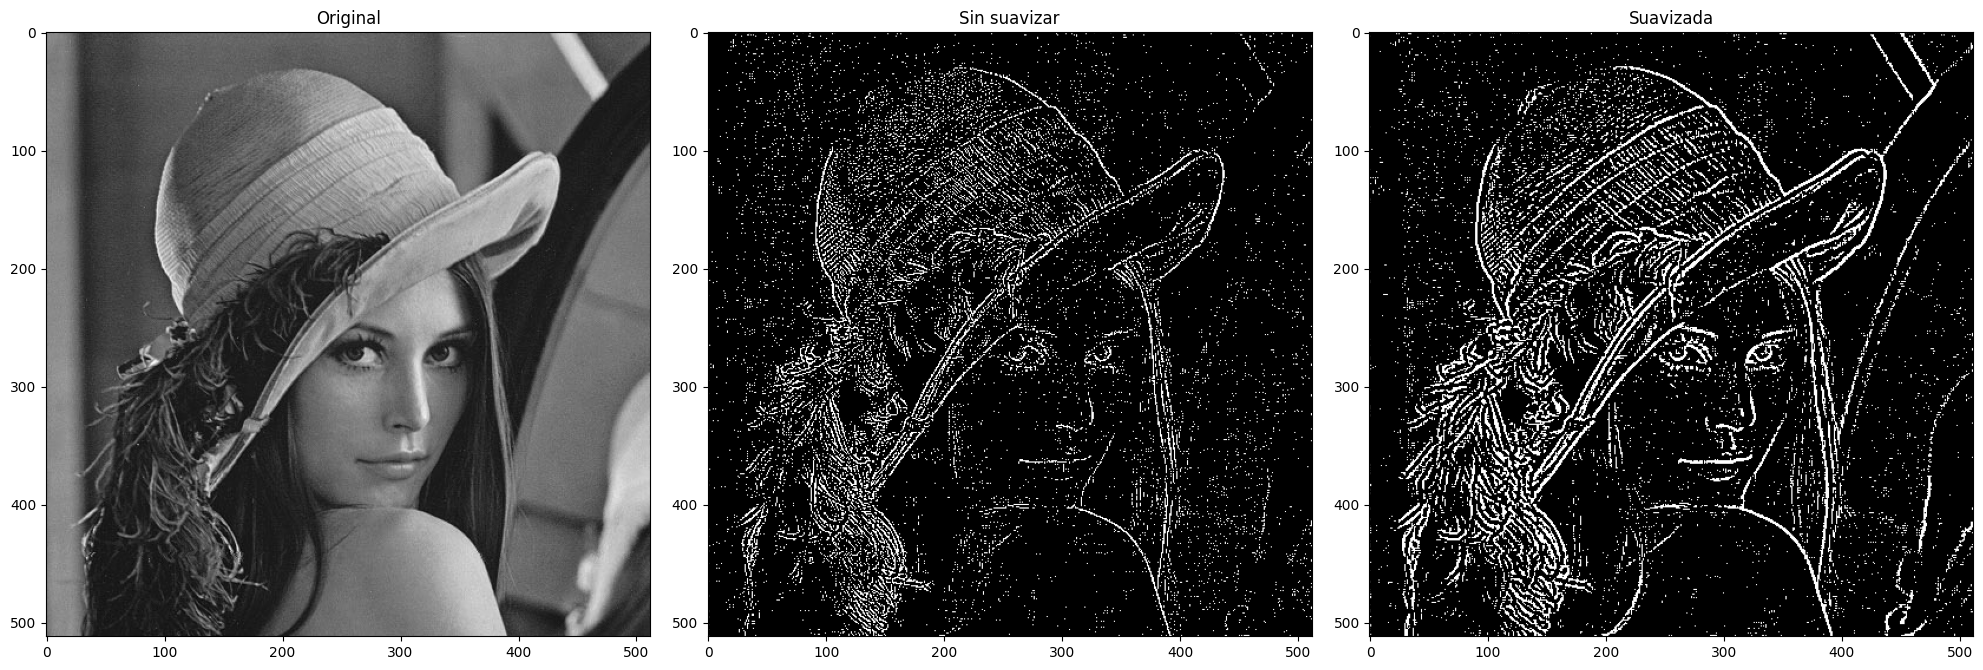

In [64]:
fig, ax = plt.subplots(1, 3, figsize=(20,10))
fig.tight_layout()
plt.clf()

plt.subplot(1,3,1)
plt.imshow(gray, cmap="gray")
plt.title("Original")
plt.subplot(1,3,2)
plt.imshow(255-dst, cmap="binary")
plt.title("Sin suavizar")
plt.subplot(1,3,3)
plt.imshow(255-dst_s, cmap="binary")
plt.title("Suavizada")

# Mediana

## Ruido sal y pimienta

In [65]:
def add_noise(img):
    row, col = img.shape
    number_of_pixels = random.randint(1000, 10000)
    for i in range(number_of_pixels):
        y_coord = random.randint(0, row - 1)
        x_coord = random.randint(0, col - 1)
        img[y_coord][x_coord] = 255

    number_of_pixels = random.randint(1000, 10000)
    for i in range(number_of_pixels):
        y_coord = random.randint(0, row - 1)
        x_coord = random.randint(0, col - 1)
        img[y_coord][x_coord] = 0
    return img

## Filtro de la mediana

In [70]:
I1 = cv2.imread("lena.bmp")

# BOX
n = 3
h = np.ones((n, n), np.float32)/(n*n)

gray = cv2.cvtColor(I1, cv2.COLOR_BGR2GRAY)

ruido = add_noise(gray)

ruido_box = cv2.filter2D(ruido, -1, h)
dst = cv2.medianBlur(ruido, 3)

Resultados

Text(0.5, 1.0, 'Mediana')

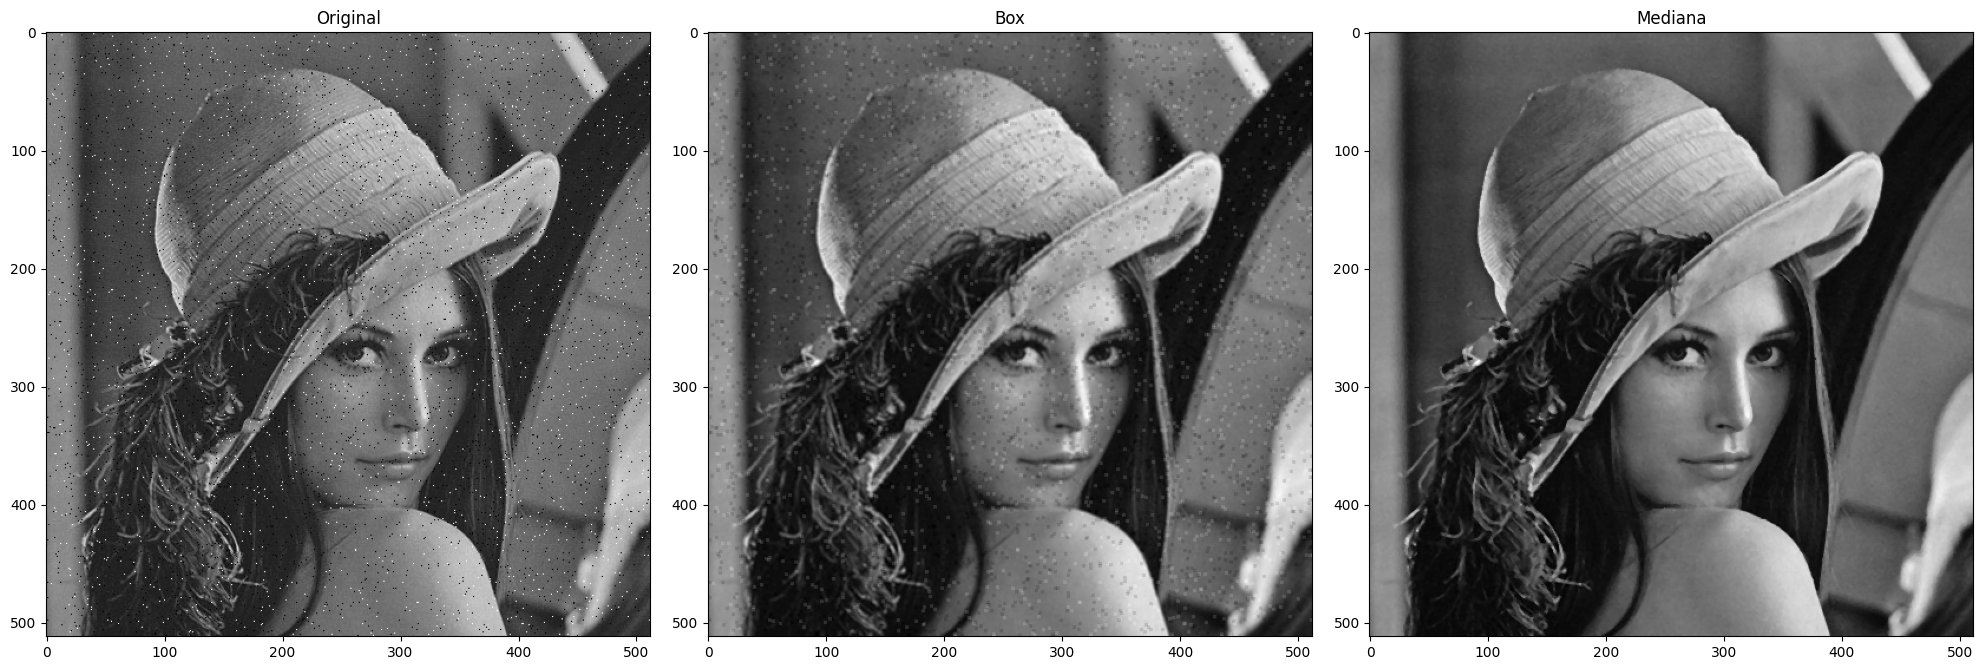

In [71]:
fig, ax = plt.subplots(1, 3, figsize=(20,10))
fig.tight_layout()
plt.clf()

plt.subplot(1,3,1)
plt.imshow(ruido, cmap="gray")
plt.title("Original")
plt.subplot(1,3,2)
plt.imshow(ruido_box, cmap="gray")
plt.title("Box")
plt.subplot(1,3,3)
plt.imshow(dst, cmap="gray")
plt.title("Mediana")